In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# FASE 1: INGESTA Y SUAVIZADO DE DATOS
# ==========================================

# 1. DEFINIR NOMBRES DE COLUMNAS Y PARÁMETROS
# Basado en el paper, el archivo no tiene cabeceras. Las columnas son:
# Humedad, Temperatura, y las resistencias (en kΩ) de 6 sensores (2 de cada tipo).
nombres_columnas = [
    'Humedad_%', 'Temperatura_C', 
    'MQ3_1', 'MQ4_1', 'MQ6_1', 
    'MQ3_2', 'MQ4_2', 'MQ6_2'
]

# Frecuencia de muestreo del paper: 18.5 Hz (18.5 lecturas por segundo)
frecuencia_muestreo = 18.5

# 2. CARGAR EL ARCHIVO CRUDO
# Usamos sep='\s+' porque los datos están separados por tabulaciones/espacios
archivo_prueba = 'AQ_Wines\AQ_Wine01-B01_R02.txt'
df_crudo = pd.read_csv(archivo_prueba, sep='\s+', header=None, names=nombres_columnas)

# 3. CREAR EL EJE TEMPORAL REAL
# Como sabemos que cada fila es un "tick" a 18.5 Hz, calculamos el tiempo exacto en segundos
df_crudo['Tiempo_s'] = df_crudo.index / frecuencia_muestreo

# 4. CONFIGURAR LA MEDIA MÓVIL (N)
# Si 1 segundo son 18.5 muestras, una ventana N=9 equivale a promediar ~0.5 segundos de datos.
N = 9 
columnas_sensores = ['MQ3_1', 'MQ4_1', 'MQ6_1', 'MQ3_2', 'MQ4_2', 'MQ6_2']

# 5. APLICAR EL FILTRO DE MEDIA MÓVIL CENTRADO (LA CORRECCIÓN)
df_limpio = df_crudo.copy()

# Añadimos center=True para calcular la media hacia ambos lados y evitar el desfase
df_limpio[columnas_sensores] = df_crudo[columnas_sensores].rolling(window=N, center=True).mean()

# Eliminamos los valores nulos (ahora el filtro genera NaNs al principio y al final de la serie)
df_limpio = df_limpio.dropna().reset_index(drop=True)

df_limpio

<>:23: SyntaxWarning: invalid escape sequence '\A'
<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\A'
<>:24: SyntaxWarning: invalid escape sequence '\s'
C:\Users\jesus.veiga\AppData\Local\Temp\ipykernel_25724\171124449.py:23: SyntaxWarning: invalid escape sequence '\A'
  archivo_prueba = 'AQ_Wines\AQ_Wine01-B01_R02.txt'
C:\Users\jesus.veiga\AppData\Local\Temp\ipykernel_25724\171124449.py:24: SyntaxWarning: invalid escape sequence '\s'
  df_crudo = pd.read_csv(archivo_prueba, sep='\s+', header=None, names=nombres_columnas)


,Humedad_%,Temperatura_C,MQ3_1,MQ4_1,MQ6_1,MQ3_2,MQ4_2,MQ6_2,Tiempo_s
0,13.00,34.00,141.584167,60.353689,183.518033,652.656744,60.490833,156.534044,0.216216
1,13.00,34.00,141.566700,60.373289,183.545567,652.210144,60.500656,156.544444,0.270270
2,13.00,34.00,141.549222,60.395333,183.559322,652.061867,60.515378,156.554844,0.324324
3,13.00,34.00,141.575433,60.414911,183.559322,652.061867,60.527656,156.575644,0.378378
4,13.00,34.00,141.592878,60.429589,183.559322,651.765900,60.539933,156.596422,0.432432
...,...,...,...,...,...,...,...,...,...
3317,22.84,38.94,16.121578,52.312733,121.271311,45.446300,45.303656,90.094222,179.513514
3318,22.32,38.84,16.153322,52.259611,121.391822,45.489300,45.284500,90.213000,179.567568
3319,21.81,38.74,16.184633,52.212467,121.532711,45.533833,45.268533,90.327878,179.621622
3320,21.29,38.65,16.215044,52.163433,121.674078,45.569489,45.254167,90.430622,179.675676


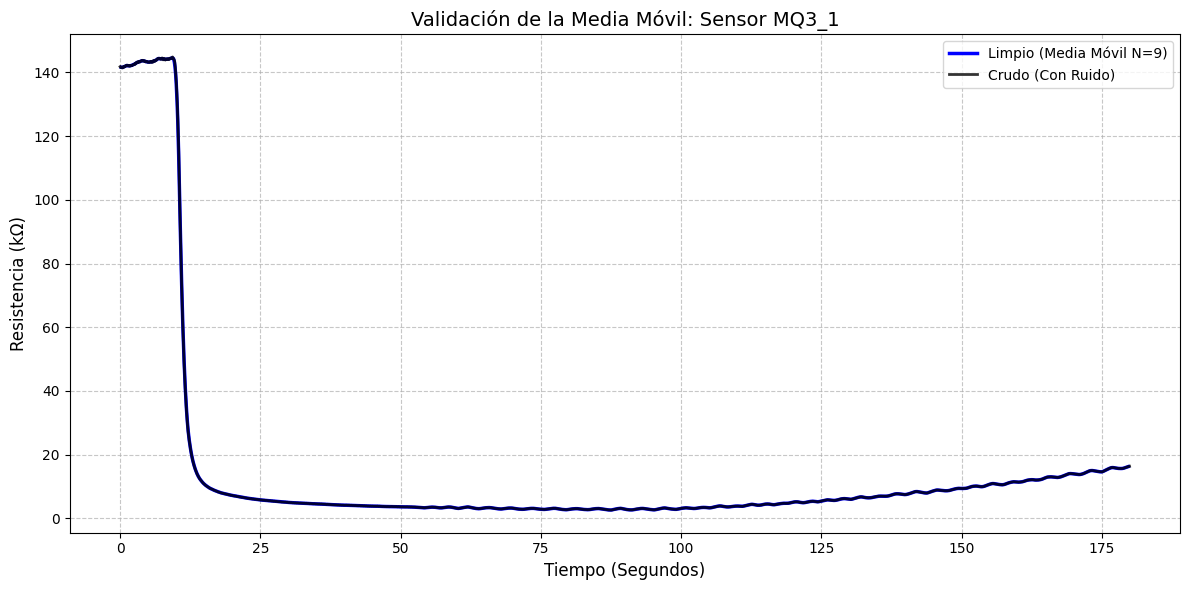

In [20]:
plt.figure(figsize=(12, 6))

# 1. Dibujamos el dato LIMPIO abajo (en azul)
plt.plot(df_limpio['Tiempo_s'], df_limpio['MQ3_1'], color='blue', label=f'Limpio (Media Móvil N={N})', linewidth=2.5)

# 2. Dibujamos el dato CRUDO encima (en negro) pero más fino para que se vea el ruido alrededor del azul
plt.plot(df_crudo['Tiempo_s'], df_crudo['MQ3_1'], color='black', label='Crudo (Con Ruido)', linewidth=2, alpha=0.8)

plt.title('Validación de la Media Móvil: Sensor MQ3_1', fontsize=14)
plt.xlabel('Tiempo (Segundos)', fontsize=12)
plt.ylabel('Resistencia (kΩ)', fontsize=12)

# Opcional: Descomenta esta línea si quieres ver el comportamiento exacto al inicio
# plt.xlim(0, 10) 

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Fase 2: Normalización por linea base

En esta etapa, nuestro objetivo es convertir las curvas de resistencia absoluta (que están en kiloohmios, $k\Omega$) en una escala adimensional de Sensibilidad de Respuesta ($Rs$). Esto nos permitirá eliminar el impacto de la deriva de los sensores, las diferencias de fabricación y las variaciones de temperatura o humedad del laboratorio.La fórmula matemática que vamos a implementar en nuestro código es:$$Rs = \frac{R_0 - R_t}{R_0}$$Donde:$R_0$: Es la resistencia base del sensor en estado de reposo (aire limpio).$R_t$: Es la resistencia medida en cada instante de tiempo real.

¿Cómo vamos a calcular $R_0$ empíricamente?Como vimos en el análisis del paper, el gas no impacta al sensor inmediatamente en el segundo cero. Los primeros segundos de la medición registran el aire limpio de la cámara.Para evitar cualquier micro-fluctuación, la mejor práctica de ingeniería es calcular el promedio de los primeros 2 segundos de nuestra señal ya suavizada para fijar el $R_0$ de cada sensor. Como muestreamos a $18.5\text{ Hz}$, 2 segundos equivalen aproximadamente a las primeras 37 filas de nuestro DataFrame.

<>:13: SyntaxWarning: invalid escape sequence '\A'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\A'
<>:13: SyntaxWarning: invalid escape sequence '\s'
C:\Users\jesus.veiga\AppData\Local\Temp\ipykernel_25724\229475359.py:13: SyntaxWarning: invalid escape sequence '\A'
  df_crudo = pd.read_csv('AQ_Wines\AQ_Wine01-B01_R02.txt', sep='\s+', header=None, names=nombres_columnas)
C:\Users\jesus.veiga\AppData\Local\Temp\ipykernel_25724\229475359.py:13: SyntaxWarning: invalid escape sequence '\s'
  df_crudo = pd.read_csv('AQ_Wines\AQ_Wine01-B01_R02.txt', sep='\s+', header=None, names=nombres_columnas)


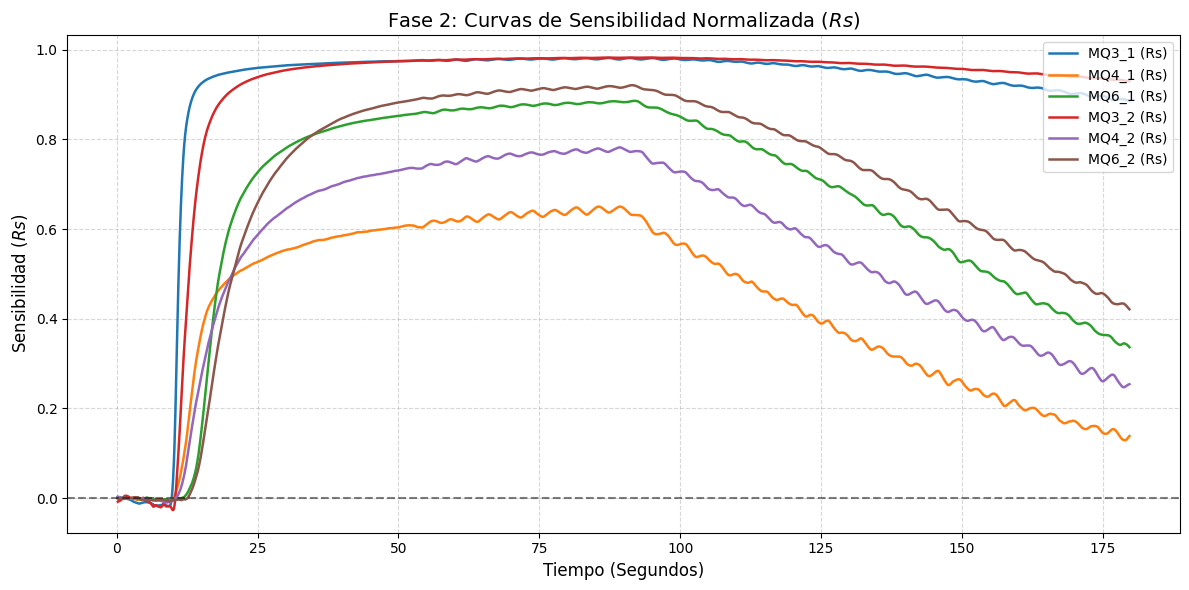

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========================================================
# RECAPITULACIÓN FASE 1: CARGA Y SUAVIZADO (CÓDIGO ANTERIOR)
# ========================================================
nombres_columnas = ['Humedad_%', 'Temperatura_C', 'MQ3_1', 'MQ4_1', 'MQ6_1', 'MQ3_2', 'MQ4_2', 'MQ6_2']
frecuencia_muestreo = 18.5
N = 9 
columnas_sensores = ['MQ3_1', 'MQ4_1', 'MQ6_1', 'MQ3_2', 'MQ4_2', 'MQ6_2']

df_crudo = pd.read_csv('AQ_Wines\AQ_Wine01-B01_R02.txt', sep='\s+', header=None, names=nombres_columnas)
df_crudo['Tiempo_s'] = df_crudo.index / frecuencia_muestreo

df_limpio = df_crudo.copy()
df_limpio[columnas_sensores] = df_crudo[columnas_sensores].rolling(window=N, center=True).mean()
df_limpio = df_limpio.dropna().reset_index(drop=True)

# ========================================================
# FASE 2: NORMALIZACIÓN POR LÍNEA BASE (SENSIBILIDAD Rs)
# ========================================================

# 1. Definir cuántas filas representan nuestro tiempo basal (ej. primeros 2 segundos)
segundos_basales = 2.0
filas_basales = int(segundos_basales * frecuencia_muestreo) # 2.0 * 18.5 = 37 filas

# 2. Crear un nuevo DataFrame para almacenar las curvas normalizadas
df_normalizado = df_limpio.copy()

# 3. Calcular R0 y aplicar la fórmula sensor por sensor
for sensor in columnas_sensores:
    # Extraemos las primeras 37 filas de la señal limpia y calculamos su media
    R0 = df_limpio[sensor].iloc[:filas_basales].mean()
    
    # Aplicamos la fórmula matemática de sensibilidad Rs = (R0 - Rt) / R0
    df_normalizado[sensor] = (R0 - df_limpio[sensor]) / R0

# ========================================================
# VALIDACIÓN VISUAL DE LA FASE 2
# ========================================================
# Graficaremos todos los sensores a la vez para comprobar que comparten la misma escala
plt.figure(figsize=(12, 6))

for sensor in columnas_sensores:
    plt.plot(df_normalizado['Tiempo_s'], df_normalizado[sensor], label=f'{sensor} (Rs)', linewidth=1.8)

plt.title('Fase 2: Curvas de Sensibilidad Normalizada ($Rs$)', fontsize=14)
plt.xlabel('Tiempo (Segundos)', fontsize=12)
plt.ylabel('Sensibilidad ($Rs$)', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.5) # Línea de referencia en cero
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [24]:
# ========================================================
# FASE 3: EXTRACCIÓN DE CARACTERÍSTICAS (ACTUALIZADO)
# ========================================================

caracteristicas_muestra = {}

for sensor in columnas_sensores:
    # 1. Obtener la serie temporal del sensor actual
    senal = df_normalizado[sensor].values
    
    # 2. Descriptor 1: Valor Máximo (Pico de respuesta)
    pico_max = np.max(senal)
    
    # 3. Descriptor 2: Área Bajo la Curva (Corregido para NumPy moderno)
    area_curva = np.trapezoid(senal, dx=dt)
    
    # 4. Descriptor 3: Pendiente Máxima de Subida (Derivada máxima)
    derivada = np.diff(senal) / dt
    pendiente_max = np.max(derivada)
    
    # Guardamos los resultados
    caracteristicas_muestra[f'{sensor}_max'] = pico_max
    caracteristicas_muestra[f'{sensor}_auc'] = area_curva
    caracteristicas_muestra[f'{sensor}_slope'] = pendiente_max

# 5. Convertir a un DataFrame de una sola fila
df_features_muestra = pd.DataFrame([caracteristicas_muestra])

# Mostrar la firma matemática limpia
pd.set_option('display.max_columns', None)
print(df_features_muestra.round(4))

   MQ3_1_max  MQ3_1_auc  MQ3_1_slope  MQ4_1_max  MQ4_1_auc  MQ4_1_slope  \
0     0.9816   161.1305       0.5773     0.6501    76.6934       0.1131   

   MQ6_1_max  MQ6_1_auc  MQ6_1_slope  MQ3_2_max  MQ3_2_auc  MQ3_2_slope  \
0     0.8858   117.4942       0.1274     0.9825   160.5034       0.2488   

   MQ4_2_max  MQ4_2_auc  MQ4_2_slope  MQ6_2_max  MQ6_2_auc  MQ6_2_slope  
0     0.7821    98.0199       0.0853     0.9206   124.0209       0.0874  
